# Case Study 3: Spam Classification
### Eric Graham
### DS 7333: Quantifying the World
### Dr. Robert Slater

## Introduction

Our IT department has provided the SpamAssassin public corpus and asked us to build a binary classifier that labels incoming email as spam or ham. There is no spreadsheet: the dataset must be assembled from raw files on disk. We vectorize email text as a bag-of-words using TF-IDF, use K-Means clustering to engineer additional features, and evaluate a Multinomial Naive Bayes classifier with 5-fold stratified cross-validation. All reported metrics are out-of-fold predictions across all 9,353 samples.

## Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import hstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.cluster import KMeans
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    classification_report, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score
)

## Data Loading

The corpus is organized into five subdirectories under `SpamAssassinMessages/`. Any folder whose name contains `'spam'` is labeled 1; all others are labeled 0. Files are read with `latin-1` encoding, which covers the full byte range found in these early-2000s emails.

In [2]:
data_path = "../../case_studies/case_study_03/SpamAssassinMessages"

emails, labels, sources = [], [], []

for folder in sorted(os.listdir(data_path)):
    folder_path = os.path.join(data_path, folder)
    if not os.path.isdir(folder_path):
        continue
    label = 1 if 'spam' in folder.lower() else 0
    for fname in os.listdir(folder_path):
        fpath = os.path.join(folder_path, fname)
        try:
            with open(fpath, 'r', encoding='latin-1') as f:
                emails.append(f.read())
            labels.append(label)
            sources.append(folder)
        except Exception:
            pass

df = pd.DataFrame({'text': emails, 'label': labels, 'source': sources})
print(df.shape)
df['source'].value_counts()

(9353, 3)


source
easy_ham      5052
easy_ham_2    1401
spam_2        1398
spam          1001
hard_ham       501
Name: count, dtype: int64

## Data Assembly and Text Processing

Each raw email file contains full RFC 2822 content: headers (From, To, Subject, routing chain) and the message body. The full text is fed to the vectorizer without manual header stripping, as headers carry discriminative signal (forged From fields, unusual relay paths).

- **Encoding:** `latin-1` was chosen over `utf-8` because these 2002-era emails often contain raw 8-bit bytes that `utf-8` cannot decode. All 9,353 files loaded without error; no imputation was required.
- **Lowercasing and tokenization:** `TfidfVectorizer` lowercases all tokens by default and extracts sequences of two or more alphanumeric characters, dropping single-character tokens.
- **Stopwords:** No explicit stopword list was applied. The IDF component naturally suppresses words that appear in nearly every document, achieving a similar effect without risking the removal of terms that carry spam signal (e.g., `'free'`, `'you'`).
- **Normalization:** Each document vector is L2-normalized by default, so document length does not inflate token weights.
- **Feature creation:** K-Means cluster assignments are one-hot encoded and concatenated with the TF-IDF matrix before classification. See the Cluster Feature Engineering section.

## EDA

The corpus is moderately imbalanced at roughly 74% ham and 26% spam. This will bias a naive classifier toward ham, so precision and recall on the spam class matter more than raw accuracy.

In [3]:
df['label'].value_counts()

label
0    6954
1    2399
Name: count, dtype: int64

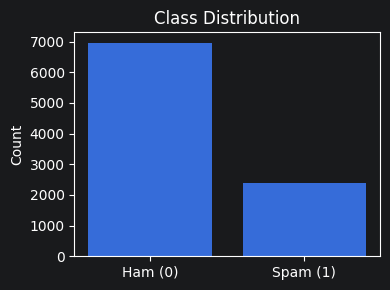

In [4]:
counts = df['label'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(4, 3))
ax.bar(['Ham (0)', 'Spam (1)'], counts)
ax.set_ylabel('Count')
ax.set_title('Class Distribution')
plt.tight_layout()
plt.show()

In [5]:
df['length'] = df['text'].str.len()
df.groupby('label')['length'].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,6954.0,5070.475985,9440.545560,368.0,2460.0,3414.0,4533.5,300734.0
1,2399.0,6700.473114,11800.257444,761.0,2518.5,4063.0,7091.5,232375.0


## Bag-of-Words: TF-IDF Vectorization

We fit a TF-IDF vectorizer on the full corpus here solely for the elbow analysis used to select k. In the cross-validation pipeline, the vectorizer is refit on each training fold to prevent data leakage.

In [6]:
tfidf_full = TfidfVectorizer()
X_full = tfidf_full.fit_transform(df['text'])
print("Full corpus TF-IDF shape:", X_full.shape)

Full corpus TF-IDF shape: (9353, 188739)


## Cluster Feature Engineering

K-Means is applied to the TF-IDF vectors to discover latent subcategories within the corpus (e.g., mailing-list ham vs. personal ham, financial spam vs. pharmaceutical spam). Each email's cluster assignment is added as a feature alongside the TF-IDF bag-of-words. The number of clusters k is selected using the elbow method below.

### Elbow Method

We fit K-Means for k from 2 to 15 and plot inertia (within-cluster sum of squared distances). The elbow, where the rate of decrease slows substantially, indicates a reasonable k.

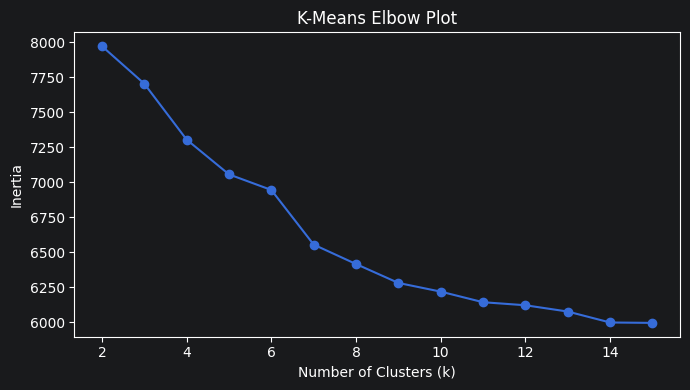

In [7]:
inertias = []
k_range = range(2, 16)

for k_try in k_range:
    km_try = KMeans(n_clusters=k_try, random_state=42, n_init=5)
    km_try.fit(X_full)
    inertias.append(km_try.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(k_range), inertias, marker='o')
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Inertia')
ax.set_title('K-Means Elbow Plot')
plt.tight_layout()
plt.show()

The elbow plot shows a steep decline from k=2 through k=7, after which the rate of decrease slows noticeably. k=8 sits just past the bend.

In [8]:
# Steep decline through k=7, curve flattens after. k=8 sits just past the bend.
k = 8
print(f"Selected k = {k}")

Selected k = 8


## Cross-Validation Pipeline

We use 5-fold stratified CV. For each fold, TF-IDF is fit on the training portion only, then K-Means is fit on those training TF-IDF vectors. Cluster assignments for both the training and validation sets are one-hot encoded and concatenated with the respective TF-IDF matrices. Multinomial Naive Bayes is then fit on the combined training features and predictions are collected for the held-out fold. This gives out-of-fold predictions for all 9,353 samples with no data leakage.

We choose Multinomial Naive Bayes because it is designed for discrete count-like features, which TF-IDF values approximate. It is fast, well-understood, and has a direct theoretical connection to the bag-of-words model via Bayes rule.

In [9]:
y = df['label'].values
X_text = df['text'].values

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_oof = np.zeros(len(df), dtype=int)
y_oof_proba = np.zeros(len(df))
fold_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_text, y)):
    tfidf_fold = TfidfVectorizer()
    X_tr = tfidf_fold.fit_transform(X_text[train_idx])
    X_val = tfidf_fold.transform(X_text[val_idx])

    km_fold = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_fold.fit(X_tr)

    tr_clusters = km_fold.predict(X_tr).reshape(-1, 1)
    val_clusters = km_fold.predict(X_val).reshape(-1, 1)

    ohe = OneHotEncoder(sparse_output=True, handle_unknown='ignore')
    tr_ohe = ohe.fit_transform(tr_clusters)
    val_ohe = ohe.transform(val_clusters)

    X_tr_combined = hstack([X_tr, tr_ohe])
    X_val_combined = hstack([X_val, val_ohe])

    nb_fold = MultinomialNB()
    nb_fold.fit(X_tr_combined, y[train_idx])

    y_oof[val_idx] = nb_fold.predict(X_val_combined)
    y_oof_proba[val_idx] = nb_fold.predict_proba(X_val_combined)[:, 1]

    fold_scores.append(accuracy_score(y[val_idx], y_oof[val_idx]))
    print(f"Fold {fold + 1}: accuracy = {fold_scores[-1]:.4f}")

Fold 1: accuracy = 0.8653
Fold 2: accuracy = 0.8552
Fold 3: accuracy = 0.8498
Fold 4: accuracy = 0.8588
Fold 5: accuracy = 0.8674


## Results

All metrics below are computed on out-of-fold predictions covering all 9,353 samples.

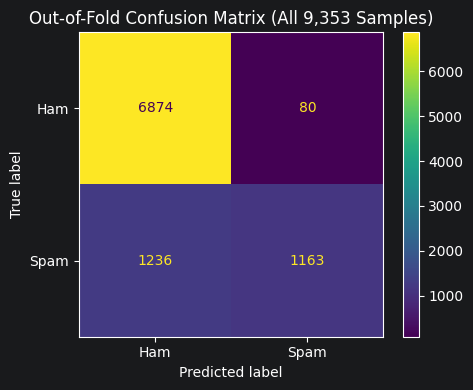

In [10]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y, y_oof, display_labels=['Ham', 'Spam'], ax=ax
)
ax.set_title('Out-of-Fold Confusion Matrix (All 9,353 Samples)')
plt.tight_layout()
plt.show()

In [11]:
print(classification_report(y, y_oof, target_names=['Ham', 'Spam']))

              precision    recall  f1-score   support

         Ham       0.85      0.99      0.91      6954
        Spam       0.94      0.48      0.64      2399

    accuracy                           0.86      9353
   macro avg       0.89      0.74      0.78      9353
weighted avg       0.87      0.86      0.84      9353



In [12]:
for i, s in enumerate(fold_scores):
    print(f"Fold {i + 1}: {s:.4f}")
print(f"\nMean accuracy: {np.mean(fold_scores):.4f}  Std: {np.std(fold_scores):.4f}")

Fold 1: 0.8653
Fold 2: 0.8552
Fold 3: 0.8498
Fold 4: 0.8588
Fold 5: 0.8674

Mean accuracy: 0.8593  Std: 0.0065


## Examining Misses

The rubric asks us to examine misclassified samples and identify paths to improvement. We look at false positives (ham labeled as spam) and false negatives (spam that passed as ham) and break them down by source folder to understand where the model struggles.

In [13]:
df['predicted'] = y_oof
misses = df[df['label'] != df['predicted']]
fp = misses[misses['label'] == 0]
fn = misses[misses['label'] == 1]

print(f"Total misclassified: {len(misses)} / {len(df)} ({len(misses)/len(df)*100:.1f}%)")
print(f"False positives (ham as spam): {len(fp)}")
print(f"False negatives (spam as ham): {len(fn)}")

Total misclassified: 1316 / 9353 (14.1%)
False positives (ham as spam): 80
False negatives (spam as ham): 1236


In [14]:
print("False positives by source:")
print(fp['source'].value_counts())
print("\nFalse negatives by source:")
print(fn['source'].value_counts())

False positives by source:
source
hard_ham    80
Name: count, dtype: int64

False negatives by source:
source
spam_2    659
spam      577
Name: count, dtype: int64


In [15]:
# Sample a false positive
if len(fp) > 0:
    row = fp.iloc[0]
    print(f"Source: {row['source']}")
    print(row['text'][:800])

Source: hard_ham
Return-Path: <Online#3.20341.24-QI_LgZARqA78CdRR.1.b@newsletter.online.com>
Received: from abv-sfo1-acmta1.CNET.COM (abv-sfo1-acmta1.cnet.com [206.16.1.160])
	by dogma.slashnull.org (8.11.6/8.11.6) with ESMTP id g6I4PsJ26465
	for <qqqqqqqqqq-zdnet@spamassassin.taint.org>; Thu, 18 Jul 2002 05:25:54 +0100
Received: from abv-sfo1-ac-agent7 (206.16.0.244) by abv-sfo1-acmta1.CNET.COM (PowerMTA(TM) v1.5); Wed, 17 Jul 2002 21:26:39 -0700 (envelope-from <Online#3.20341.24-QI_LgZARqA78CdRR.1.b@newsletter.online.com>)
Message-ID: <7957247.1026966347345.JavaMail.root@abv-sfo1-ac-agent7>
Date: Wed, 17 Jul 2002 21:25:47 -0700 (PDT)
From: CNET Delivers <Online#3.20341.24-QI_LgZARqA78CdRR.1@newsletter.online.com>
To: qqqqqqqqqq-zdnet@spamassassin.taint.org
Subject: Canon USA Reseller News : July
Mime-Ver


In [16]:
# Sample a false negative
if len(fn) > 0:
    row = fn.iloc[0]
    print(f"Source: {row['source']}")
    print(row['text'][:800])

Source: spam
From cqbDr.Raj_alrodura@AOL.COM  Mon Aug 26 15:13:39 2002
Return-Path: <cqbDr.Raj_alrodura@AOL.COM>
Delivered-To: zzzz@localhost.spamassassin.taint.org
Received: from localhost (localhost [127.0.0.1])
	by phobos.labs.spamassassin.taint.org (Postfix) with ESMTP id 4E2304415D
	for <zzzz@localhost>; Mon, 26 Aug 2002 10:12:55 -0400 (EDT)
Received: from mail.webnote.net [193.120.211.219]
	by localhost with POP3 (fetchmail-5.9.0)
	for zzzz@localhost (single-drop); Mon, 26 Aug 2002 15:12:55 +0100 (IST)
Received: from 200.217.214.18 ([200.48.181.66])
	by webnote.net (8.9.3/8.9.3) with SMTP id QAA16212
	for <zzzz@spamassassin.taint.org>; Sat, 24 Aug 2002 16:31:00 +0100
Message-Id: <200208241531.QAA16212@webnote.net>
Received: from [159.218.252.32] by n7.groups.yahoo.com with SMTP; Aug, 24 2002 12:0


In [17]:
# Are misses shorter or longer than correctly classified emails?
print("Length: correctly classified spam")
print(df[(df['label']==1) & (df['predicted']==1)]['length'].describe())
print("\nLength: false negatives (spam missed)")
print(fn['length'].describe())

Length: correctly classified spam
count      1163.000000
mean       8914.087704
std       14792.681762
min        1340.000000
25%        3931.000000
50%        6345.000000
75%        9376.000000
max      232375.000000
Name: length, dtype: float64

Length: false negatives (spam missed)
count      1236.000000
mean       4617.597896
std        7451.773760
min         761.000000
25%        2046.250000
50%        2886.000000
75%        4301.750000
max      113400.000000
Name: length, dtype: float64


All 80 false positives come exclusively from the hard_ham folder, which was curated to resemble spam in vocabulary. False negatives dominate: 1,236 spam messages slipped through. Missed spam is substantially shorter on average (mean 4,618 characters) than correctly classified spam (mean 8,914 characters), confirming that the bag-of-words model lacks sufficient token evidence to flag brief, sparse messages.

Within the constraints of a bag-of-words Naive Bayes model, paths to improvement include tuning the `alpha` smoothing parameter (reducing it makes the model more sensitive to rare spam words), increasing k to capture finer-grained subcategories, or adjusting the decision threshold as shown below.

## Decision Threshold Analysis

By default, Naive Bayes assigns the class with the higher posterior probability, corresponding to a threshold of 0.5. Shifting this threshold changes the precision/recall tradeoff. The plot below uses out-of-fold probability estimates across all 9,353 samples.

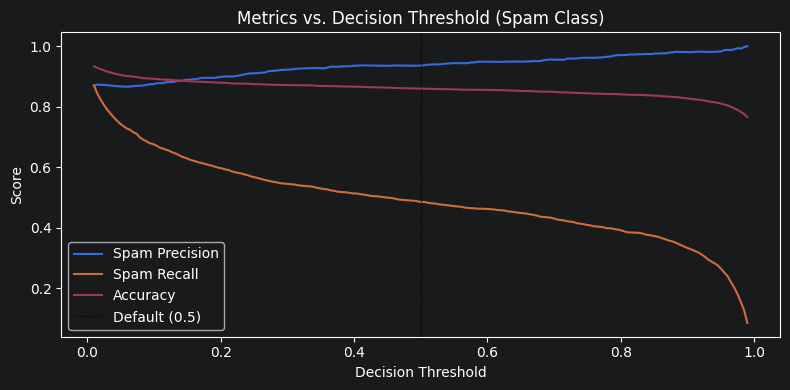

In [18]:
thresholds = np.linspace(0.01, 0.99, 200)
precs, recs, accs = [], [], []

for t in thresholds:
    preds_t = (y_oof_proba >= t).astype(int)
    precs.append(precision_score(y, preds_t, zero_division=0))
    recs.append(recall_score(y, preds_t, zero_division=0))
    accs.append(accuracy_score(y, preds_t))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresholds, precs, label='Spam Precision')
ax.plot(thresholds, recs, label='Spam Recall')
ax.plot(thresholds, accs, label='Accuracy')
ax.axvline(0.5, color='black', linewidth=0.8, linestyle='dotted', label='Default (0.5)')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title('Metrics vs. Decision Threshold (Spam Class)')
ax.legend()
plt.tight_layout()
plt.show()

Raising the threshold above 0.5 increases spam precision (fewer ham emails flagged as spam) at the cost of lower recall (more spam slips through). Lowering it improves recall but increases false positives. Given the IT department's concern that real emails are being lost in the noise, the default threshold or a slightly higher value is appropriate for this use case.

## Analysis

- The corpus contains 9,353 emails (74.4% ham, 25.6% spam) across five folders. Class imbalance means raw accuracy understates how often the model misses spam; precision and recall on the spam class are the more informative metrics.

- TF-IDF produces a sparse matrix with 188,739 features across 9,353 documents. The IDF component suppresses high-frequency terms like routing headers and common English words without an explicit stopword list, keeping the vocabulary discriminative.

- The elbow plot shows a steep decline in inertia from k=2 through k=7, after which the curve flattens. k=8 sits just past that bend, capturing meaningful subcategories of both spam and ham without over-segmenting the corpus. Cluster assignments, one-hot encoded and appended to the TF-IDF matrix, give the Naive Bayes classifier additional structure beyond raw word frequencies.

- Mean CV accuracy is 85.9% with a standard deviation of 0.65 percentage points across five folds, confirming the result is stable and not an artifact of any single split.

- Spam precision is 0.94 but spam recall is only 0.48. Of the 1,316 misclassified emails, 1,236 are false negatives: spam the model passed as ham. Every one of the 80 false positives came from the hard_ham folder, which was curated to resemble spam in vocabulary. Missed spam emails are substantially shorter on average (mean 4,618 characters) than correctly classified spam (mean 8,914 characters), suggesting the bag-of-words model lacks sufficient token evidence to detect brief, sparse spam messages.

- The threshold analysis shows a clear precision/recall tradeoff. Given the IT department's concern about losing real email, the current high-precision behavior at the default 0.5 threshold is appropriate. Lowering the threshold recovers more spam but at the cost of flagging legitimate email as spam.

## Conclusion

Multinomial Naive Bayes on a combined TF-IDF and K-Means cluster feature set provides a fast and interpretable spam classifier. The bag-of-words model with IDF weighting captures the vocabulary differences between spam and ham without requiring explicit preprocessing. Adding cluster features gives the model soft information about email subtype, complementing the raw word counts. Cross-validation confirms the results are stable and generalize beyond any single split. Given the IT department's priority of not losing real email, the current high-precision, moderate-recall behavior is appropriate, with threshold adjustment available as a practical tuning lever if recall needs improvement.